📊 Project Overview
The goal of this project was to analyze customer shopping data to identify trends in purchasing behavior, customer demographics, and sales performance.

In [2]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Successfully Loaded")

Successfully Loaded


In [3]:
# Load dataset
df=pd.read_csv(r"D:\almabetter\projects\Customer_shopping_behaviour\dataset\customer_shopping_behavior.csv")

#Data Wranggling

# Columns description
- customer_id: A unique identifier for each customer.
- age: The age of the customer.
- gender: The gender of the customer.
- item_purchased: The specific item bought by the customer.
- category: The product category of the purchased item (e.g., Clothing, Accessories).
- purchase_amount: The amount spent on the purchase in USD.
- location: The geographical location of the customer.
- size: The size of the purchased item.
- color: The color of the purchased item.
- season: The season during which the purchase was made.
- review_rating: The rating given by the customer for the purchase (on a scale of 2.5 to 5.0).
- subscription_status: Indicates whether the customer has a subscription (Yes/No).
- shipping_type: The type of shipping chosen for the order.
- discount_applied: Indicates if a discount was applied to the purchase (Yes/No).
- previous_purchases: The number of previous purchases made by the customer.
- payment_method: The method used for payment.
- frequency_of_purchases: How often the customer makes purchases.
- age_group: A categorized group based on the customer's age (e.g., Young_Adult, Adult, Middle_aged, Senior).
- purchase_frequency_days: The mapped numerical value in days for the frequency_of_purchases column.

In [4]:
# Top 5 Rows
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
# Bottom 5 rows
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [6]:
# Rows and columns
print("Total Rows",df.shape[0])
print("Total Columns",df.shape[1])

Total Rows 3900
Total Columns 18


In [7]:
#Columns
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [8]:
#Unique values
for i in df.columns:
    print(f"{i}:-- {df[i].unique()}")
    print()

Customer ID:-- [   1    2    3 ... 3898 3899 3900]

Age:-- [55 19 50 21 45 46 63 27 26 57 53 30 61 65 64 25 52 66 31 56 18 38 54 33
 36 35 29 70 69 67 20 39 42 68 49 59 47 40 41 48 22 24 44 37 58 32 62 51
 28 43 34 23 60]

Gender:-- ['Male' 'Female']

Item Purchased:-- ['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']

Category:-- ['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Purchase Amount (USD):-- [ 53  64  73  90  49  20  85  34  97  31  68  72  51  81  36  38  48  62
  37  88  22  25  56  94  79  67  91  33  69  45  60  76  39 100  21  43
  54  55  30  28  59  24  83  46  70  29  26  58  96  40  32  95  41  47
  99  87  92  98  89  35  75  65  86  84  77  27  23  74  80  42  61  82
  78  93  50  57  66  44  52  71  63]

Location:-- ['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 

In [9]:
# Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [10]:
#Statistical discription
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [12]:
#checking null values
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [13]:
# Handling null value
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [14]:
#Checking duplicates
df.duplicated().sum()

0

In [15]:
#Lower casing and removing space from columns
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')
df.rename({'purchase_amount_(usd)':'purchase_amount'},axis=1,inplace=True)

#Columns name
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [16]:
#Create a column age_group
labels=['Young_Adult','Adult','Middle_aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)

In [17]:
# Create column purchase_frequency_days
frequency_mapping={
    'Fortnightly':14,
    'Weekly':7,
    'Monthly':30,
    'Quarterly':90,
    'Bi-Weekly':14,
    'Annually':365,
    'Every 3 months':90
}

df['purchase_frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)

In [18]:
#Remove unnecessay column
print((df['discount_applied']==df['promo_code_used']).all())
df.drop("promo_code_used",axis=1,inplace=True) # remove any one

True


## Univariate Analysis

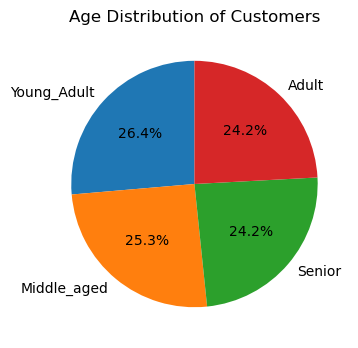

In [22]:
# Chart 1 - Age Distribution of Customers
# Count customers in each age group
age_counts = df['age_group'].value_counts()

# Plot Pie Chart
plt.figure(figsize=(4,4))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Age Distribution of Customers')
plt.show()

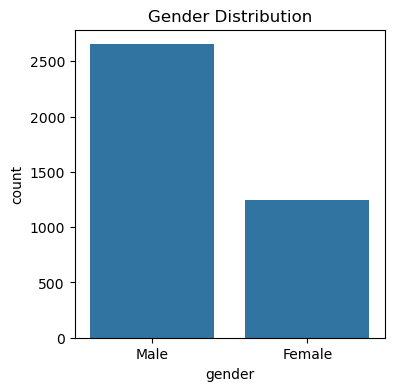

In [36]:
# Gender Distribution
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='gender')
plt.title("Gender Distribution")
plt.show()

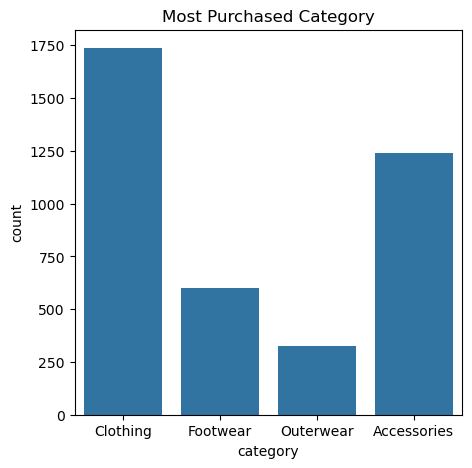

In [37]:
#Most Purchased Category
plt.figure(figsize=(5,5))
sns.countplot(data=df,x='category')
plt.title("Most Purchased Category")
plt.show()

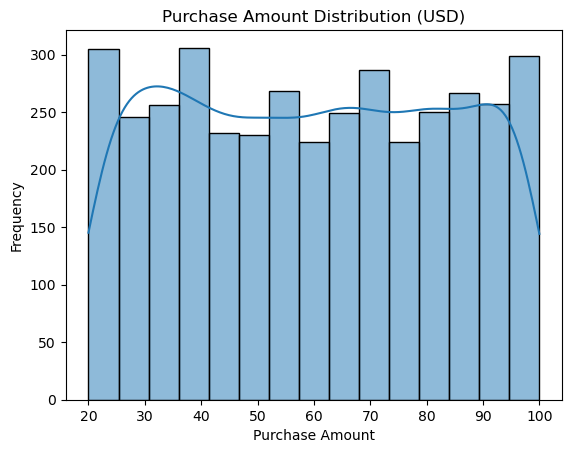

In [41]:
# Purchase Amount Distribution
plt.Figure(figsize=(5,5))
sns.histplot(data=df,x='purchase_amount',kde=True)
plt.title("Purchase Amount Distribution (USD)")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

#Bivariate Analysis

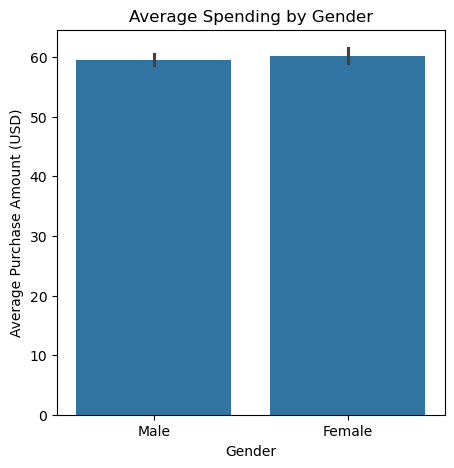

In [45]:
#Compare Male vs Female spending
plt.figure(figsize=(5,5))
sns.barplot(data=df,x='gender',y='purchase_amount',estimator='mean')
plt.title("Average Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount (USD)")
plt.show()

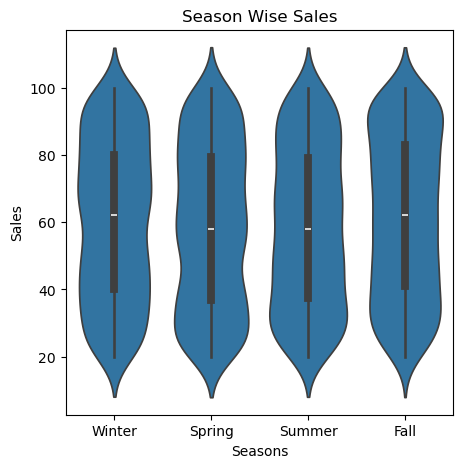

In [48]:
#season wise sale
plt.figure(figsize=(5,5))
sns.violinplot(data=df,x='season',y='purchase_amount')
plt.title("Season Wise Sales")
plt.xlabel("Seasons")
plt.ylabel("Sales")
plt.show()

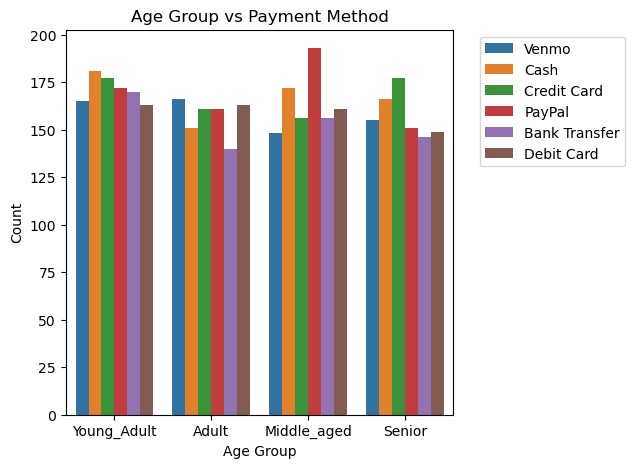

In [52]:
#age group vs payment method
plt.figure(figsize=(5,5))
sns.countplot(data=df, x='age_group', hue='payment_method')
plt.title("Age Group vs Payment Method")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

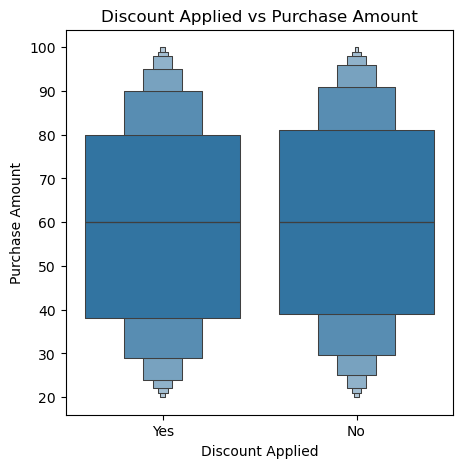

In [55]:
#discount_applied vs purchase_amount
plt.figure(figsize=(5,5))
sns.boxenplot(data=df, x='discount_applied', y='purchase_amount')
plt.title("Discount Applied vs Purchase Amount")
plt.xlabel("Discount Applied")
plt.ylabel("Purchase Amount")
plt.show()

#Multivariate Analysis

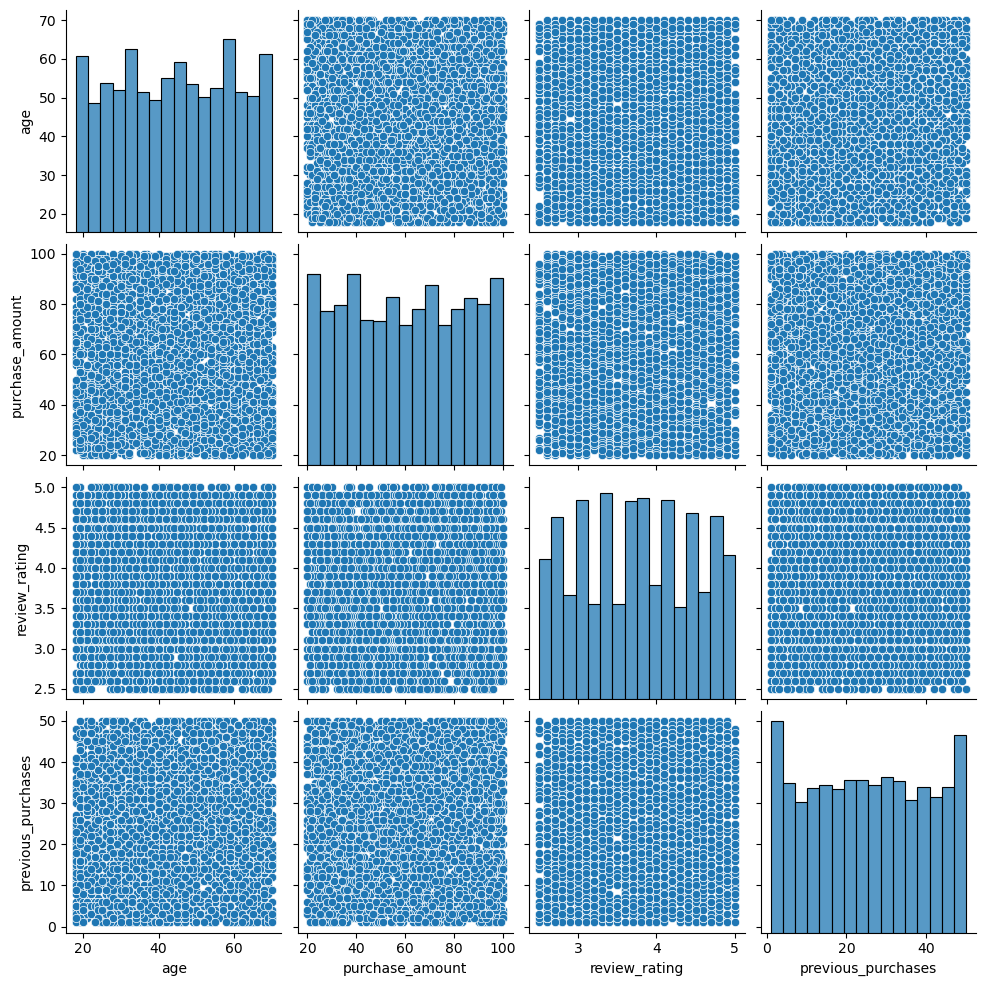

In [ ]:
#Pair Plot
# Select numerical columns
num_cols = df[['age', 'purchase_amount', 'review_rating', 'previous_purchases']]

# Pair Plot
sns.pairplot(num_cols)
plt.show()

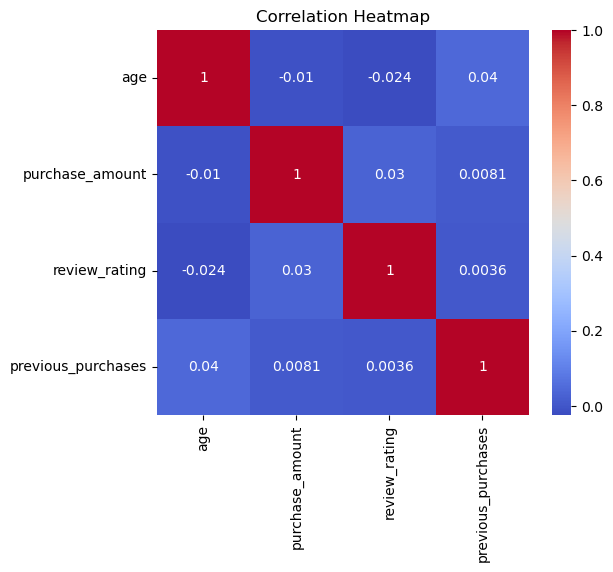

In [61]:
#Correlation Heatmap
# Correlation matrix
corr = num_cols.corr()

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Final Key Findings

- Clothing is the most popular product category.

- Male customers purchase more frequently, but female customers spend slightly more per order.

- Customers typically spend $50–$80 per purchase.

- Sales are stable across seasons.

- Credit cards and PayPal are the most preferred payment methods.

In [18]:
from sqlalchemy import create_engine

# Step 1: PostgreSQL Credentials

username = "postgres"          # default PostgreSQL username
password = "9160"          # your PostgreSQL password
host = "localhost"             # localhost if running locally
port = "5433"                  # default PostgreSQL port
database = "customer_behavior" # database name created in pgAdmin

# Step 2: Create Database Engine

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 3: Load DataFrame to PostgreSQL

table_name = "customer"  # table name in PostgreSQL
df.to_sql(
    table_name,
    engine,
    if_exists="replace",   # replace table if it already exists
    index=False
)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'customer_behavior'.
